## Setup

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [2]:
import sys
import tensorflow as tf
from tensorflow.keras import layers, models
import warnings

import matplotlib.pyplot as plt

import numpy as np
import cv2

In [3]:
sys.path.insert(0, "../src/")
warnings.filterwarnings("ignore")

In [4]:
from image_preprocessing import load_dataset

## Datasets

In [5]:
dataset_dirs = [directory for directory in os.listdir("../dataset/") if not directory.endswith('.py') and not directory.endswith('.json')]
dataset_dirs

['Garbage Classification Dataset',
 'Garbage Dataset',
 'New Trash Classfication Dataset',
 'Waste Classfication Dataset']

In [6]:
DATASET_PATH = '../dataset/Waste Classfication Dataset/balanced_waste_images'

In [7]:
train, val, classes = load_dataset(DATASET_PATH)

Found 6782 files belonging to 17 classes.
Using 5426 files for training.


2026-04-26 15:30:38.779762: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:268] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Found 6782 files belonging to 17 classes.
Using 1356 files for validation.


## MobileNet Model

In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models

def create_model(num_classes):

    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(48, 48, 3),
        alpha=0.35,
        include_top=False,
        weights='imagenet')
    base_model.trainable = False
    model = models.Sequential([
        layers.Input(shape=(48, 48, 3)),
        layers.Rescaling(1./255),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(16, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

In [9]:
model = create_model(len(classes))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling (Rescaling)       (None, 48, 48, 3)         0         
                                                                 
 mobilenetv2_0.35_224 (Func  (None, 2, 2, 1280)        410208    
 tional)                                                         
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 16)                20496     
                                                                 
 dropout (Dropout)           (None, 16)                0         
                                                                 
 dense_1 (Dense)             (None, 17)                2

## Model Training

In [10]:
EPOCHS = 20

os.makedirs('models', exist_ok=True)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("models/model_mobilenet.h5", monitor="val_accuracy", save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)]

history = model.fit(train, validation_data=val, epochs=EPOCHS, callbacks=callbacks)

Epoch 1/20
170/170 [==============================] - ETA: 0s - loss: 2.6099 - accuracy: 0.1703
Epoch 1: val_accuracy improved from -inf to 0.35472, saving model to models/model_mobilenet.h5
170/170 [==============================] - 10s 42ms/step - loss: 2.6099 - accuracy: 0.1703 - val_loss: 2.1352 - val_accuracy: 0.3547
Epoch 2/20
170/170 [==============================] - ETA: 0s - loss: 2.1834 - accuracy: 0.2997
Epoch 2: val_accuracy improved from 0.35472 to 0.46903, saving model to models/model_mobilenet.h5
170/170 [==============================] - 6s 38ms/step - loss: 2.1834 - accuracy: 0.2997 - val_loss: 1.8551 - val_accuracy: 0.4690
Epoch 3/20
170/170 [==============================] - ETA: 0s - loss: 1.9598 - accuracy: 0.3708
Epoch 3: val_accuracy improved from 0.46903 to 0.50885, saving model to models/model_mobilenet.h5
170/170 [==============================] - 5s 30ms/step - loss: 1.9598 - accuracy: 0.3708 - val_loss: 1.6341 - val_accuracy: 0.5088
Epoch 4/20
170/170 [====

## Evaluation

In [11]:
test_loss, test_accuracy = model.evaluate(val)
print(f"\nValidation Loss: {test_loss:.4f}")
print(f"Validation Accuracy: {test_accuracy:.4f}")

43/43 [==============================] - 1s 31ms/step - loss: 1.3191 - accuracy: 0.5973

Validation Loss: 1.3191
Validation Accuracy: 0.5973


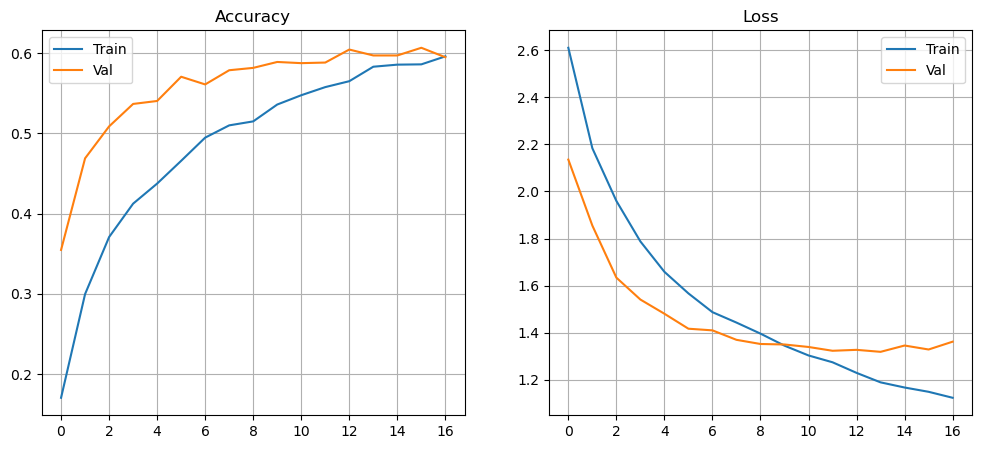

In [12]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()
plt.grid()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()
plt.grid()

plt.show()

## Saving the model

In [13]:
model.save("models/mobile_net_model_v1.keras")
print(f"Model Saved")

Model Saved


1/1 [==============================] - -0s -51420us/step
Prediction: Player
Confidence: 0.18372238


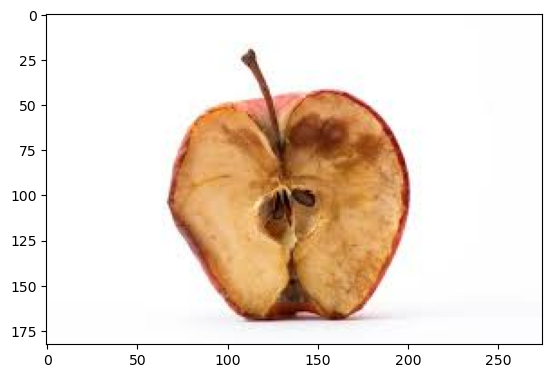

In [14]:
model = tf.keras.models.load_model("models/mobile_net_model_v1.keras")
IMG_SIZE = 48

# Load test image
img = cv2.imread("test-images/images.jpeg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)

# Preprocess (MUST match training)
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_norm = img_resized / 255.0
img_input = np.expand_dims(img_norm, axis=0)

# Predict
pred = model.predict(img_input)

pred_idx = np.argmax(pred)
confidence = pred[0][pred_idx]

print("Prediction:", classes[pred_idx])
print("Confidence:", confidence)

## Converting to TFLite

In [15]:
model = tf.keras.models.load_model("models/mobile_net_model_v1.keras")
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("models/mobile_net_model_v1.tflite", "wb") as f:
    f.write(tflite_model)

print("Saved basic TFLite model")

INFO:tensorflow:Assets written to: /tmp/tmptj3nsm0z/assets


INFO:tensorflow:Assets written to: /tmp/tmptj3nsm0z/assets


Saved basic TFLite model


## Size Comparison

In [16]:
import os

keras_path = "models/mobile_net_model_v1.keras"
tflite_path = "models/mobile_net_model_v1.tflite"

def get_size(path):
    size_bytes = os.path.getsize(path)
    size_kb = size_bytes / 1024
    size_mb = size_kb / 1024
    return size_bytes, size_kb, size_mb

# Get sizes
k_bytes, k_kb, k_mb = get_size(keras_path)
t_bytes, t_kb, t_mb = get_size(tflite_path)

print("Keras Model:")
print(f"{k_bytes} bytes | {k_kb:.2f} KB | {k_mb:.2f} MB")

print("TFLite Model:")
print(f"{t_bytes} bytes | {t_kb:.2f} KB | {t_mb:.2f} MB")

reduction = ((k_mb - t_mb) / k_mb) * 100
print(f"Size Reduction: {reduction:.2f}%")

Keras Model:
2422213 bytes | 2365.44 KB | 2.31 MB
TFLite Model:
1679232 bytes | 1639.88 KB | 1.60 MB
Size Reduction: 30.67%


## Quantization

In [17]:
model = tf.keras.models.load_model("models/mobile_net_model_v1.keras")

def representative_data_gen():
    for images, _ in train.take(100):
        yield [images]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen

converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.uint8
converter.inference_output_type = tf.uint8
tflite_quant = converter.convert()

with open("models/model_openmv_v1.tflite", "wb") as f:
    f.write(tflite_quant)

print("Quantized model saved")

INFO:tensorflow:Assets written to: /tmp/tmpfc4ev_nn/assets


INFO:tensorflow:Assets written to: /tmp/tmpfc4ev_nn/assets


Quantized model saved


fully_quantize: 0, inference_type: 6, input_inference_type: UINT8, output_inference_type: UINT8


In [18]:
import os

size = os.path.getsize("models/model_openmv_v1.tflite") / (1024 * 1024)
print(f"Quantized model size: {size:.2f} MB")

Quantized model size: 0.62 MB


In [19]:
interpreter = tf.lite.Interpreter(model_path="models/model_openmv_v1.tflite")
interpreter.allocate_tensors()
interpreter.get_input_details()

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


[{'name': 'serving_default_input_2:0',
  'index': 0,
  'shape': array([ 1, 48, 48,  3], dtype=int32),
  'shape_signature': array([-1, 48, 48,  3], dtype=int32),
  'dtype': numpy.uint8,
  'quantization': (1.0, 0),
  'quantization_parameters': {'scales': array([1.], dtype=float32),
   'zero_points': array([0], dtype=int32),
   'quantized_dimension': 0},
  'sparsity_parameters': {}}]

## Apply Pruning

In [20]:
import tensorflow_model_optimization as tfmot

PRUNING_EPOCHS = 5

# Calculate end_step from the dataset
steps_per_epoch = len(train)  # number of batches
end_step = steps_per_epoch * PRUNING_EPOCHS

pruning_params = {
    'pruning_schedule': tfmot.sparsity.keras.PolynomialDecay(
        initial_sparsity=0.0,
        final_sparsity=0.80,
        begin_step=0,
        end_step=end_step
    )
}

# Only prune Dense layers — prune_low_magnitude can't wrap frozen MobileNetV2 layers
def apply_pruning_to_dense(layer):
    if isinstance(layer, tf.keras.layers.Dense):
        return tfmot.sparsity.keras.prune_low_magnitude(layer, **pruning_params)
    return layer

pruned_model = tf.keras.models.clone_model(
    model,
    clone_function=apply_pruning_to_dense,
)
pruned_model.build((None, 48, 48, 3))

# Map original weights by layer name, copy only the trainable kernel/bias
orig_weights = {layer.name: layer.get_weights() for layer in model.layers if layer.get_weights()}

for layer in pruned_model.layers:
    # Strip the pruning wrapper name suffix to find the original layer
    base_name = layer.name.replace("prune_low_magnitude_", "")
    if base_name in orig_weights:
        try:
            layer.set_weights(orig_weights[base_name])
        except ValueError:
            # Pruned layer expects [kernel, bias, kernel_mask, kernel_threshold]
            # — set only kernel + bias, leave mask/threshold at their defaults
            orig_w = orig_weights[base_name]
            pruned_w = layer.get_weights()
            pruned_w[:len(orig_w)] = orig_w
            layer.set_weights(pruned_w)

In [21]:
pruned_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),  # lower LR for fine-tuning
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    tfmot.sparsity.keras.UpdatePruningStep(),  # required — updates sparsity each step
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
]

pruned_model.fit(train, validation_data=val, epochs=PRUNING_EPOCHS, callbacks=callbacks)

Epoch 1/5
170/170 [==============================] - 11s 44ms/step - loss: 1.1654 - accuracy: 0.5875 - val_loss: 1.3442 - val_accuracy: 0.6047
Epoch 2/5
170/170 [==============================] - 8s 47ms/step - loss: 1.4052 - accuracy: 0.5158 - val_loss: 1.6109 - val_accuracy: 0.4794
Epoch 3/5
170/170 [==============================] - 6s 37ms/step - loss: 1.8522 - accuracy: 0.3668 - val_loss: 2.0995 - val_accuracy: 0.3149
Epoch 4/5
170/170 [==============================] - 6s 37ms/step - loss: 2.2011 - accuracy: 0.2353 - val_loss: 2.1872 - val_accuracy: 0.2264


In [22]:
## Strip Pruning Wrappers & Save

# Must strip before saving/converting — otherwise model stays large
final_model = tfmot.sparsity.keras.strip_pruning(pruned_model)

final_model.save('models/mobile_net_pruned_v1.keras')

# Convert pruned model to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(final_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_pruned = converter.convert()

with open('models/model_pruned.tflite', 'wb') as f:
    f.write(tflite_pruned)

size = os.path.getsize('models/model_pruned.tflite') / (1024 * 1024)
print(f'Pruned TFLite model size: {size:.2f} MB')

INFO:tensorflow:Assets written to: /tmp/tmplknhlgo7/assets


INFO:tensorflow:Assets written to: /tmp/tmplknhlgo7/assets


Pruned TFLite model size: 0.54 MB


In [23]:
final_model = tfmot.sparsity.keras.strip_pruning(pruned_model)

def representative_data_gen():
    for images, _ in train.take(100):
        yield [tf.cast(images, tf.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(final_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.uint8
converter.inference_output_type = tf.uint8

tflite_pruned_quant = converter.convert()

with open("models/model_pruned_int8.tflite", "wb") as f:
    f.write(tflite_pruned_quant)

size = os.path.getsize("models/model_pruned_int8.tflite") / (1024 * 1024)
print(f"Pruned + INT8 model size: {size:.2f} MB")

INFO:tensorflow:Assets written to: /tmp/tmpl07zvwj2/assets


INFO:tensorflow:Assets written to: /tmp/tmpl07zvwj2/assets


Pruned + INT8 model size: 0.62 MB


fully_quantize: 0, inference_type: 6, input_inference_type: UINT8, output_inference_type: UINT8
